<a href="https://colab.research.google.com/github/kireykale/Broadway-Project/blob/Broadway_Final_Assignments/Alexa_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem.porter import PorterStemmer
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import pickle
import re

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Load Data

In [ ]:
from google.colab import files
files.upload()

Saving amazon_alexa.tsv to amazon_alexa.tsv


{'amazon_alexa.tsv': b'\xef\xbb\xbfrating\tdate\tvariation\tverified_reviews\tfeedback\r\n5\t31-Jul-18\tCharcoal Fabric \tLove my Echo!\t1\r\n5\t31-Jul-18\tCharcoal Fabric \tLoved it!\t1\r\n4\t31-Jul-18\tWalnut Finish \t"Sometimes while playing a game, you can answer a question correctly but Alexa says you got it wrong and answers the same as you.  I like being able to turn lights on and off while away from home."\t1\r\n5\t31-Jul-18\tCharcoal Fabric \t"I have had a lot of fun with this thing. My 4 yr old learns about dinosaurs, i control the lights and play games like categories. Has nice sound when playing music as well."\t1\r\n5\t31-Jul-18\tCharcoal Fabric \tMusic\t1\r\n5\t31-Jul-18\tHeather Gray Fabric \t"I received the echo as a gift. I needed another Bluetooth or something to play music easily accessible, and found this smart speaker. Can\xe2\x80\x99t wait to see what else it can do."\t1\r\n3\t31-Jul-18\tSandstone Fabric \t"Without having a cellphone, I cannot use many of her feat

In [ ]:
data = pd.read_csv(r"/content/amazon_alexa.tsv", delimiter='\t', quoting=3)
print(f"Dataset Shape: {data.shape}")

Dataset Shape: (3150, 5)


In [ ]:
data.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [ ]:
feature_name = data.columns.values
print(f"Features are: {feature_name}")

Features are: ['rating' 'date' 'variation' 'verified_reviews' 'feedback']


## EDA

In [ ]:
data.isnull().sum()

,0
rating,0
date,0
variation,0
verified_reviews,1
feedback,0


In [ ]:
data[data['verified_reviews'].isna()==True]

,rating,date,variation,verified_reviews,feedback
473,2,29-Jun-18,White,NaN,0


In [ ]:
data.dropna(inplace=True)

In [ ]:
print(f"Dataset Shape after deleting null values: {data.shape}")

Dataset Shape after deleting null values: (3149, 5)


In [ ]:
data["Length"]  = data["verified_reviews"].apply(len)
data.head()

,rating,date,variation,verified_reviews,feedback,Length
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1,197
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1,174
4,5,31-Jul-18,Charcoal Fabric,Music,1,5


In [ ]:
data.dtypes

,0
rating,int64
date,object
variation,object
verified_reviews,object
feedback,int64
Length,int64


### Anazlyzing rating Column

In [ ]:
len(data)

3149

In [ ]:
data["rating"].value_counts()

,count
rating,
5,2286
4,455
1,161
3,152
2,95


it is seen that more than 70% of data is 5* rating, imbalance dataset

### Analyzing Feedback Column

In [ ]:
data["feedback"].value_counts()

,count
feedback,
1,2893
0,256


here as according to the dataset, 1 = positive feedback, 0 =  negative feedback
rating 3,4,5 is feedback 1, rating 1,2 is feedback 0

In [ ]:
 print(f"Feedback value count - percentage distibution: \n{round(data['feedback'].value_counts()/data.shape[0]*100,2)}")

Feedback value count - percentage distibution: 
feedback
1    91.87
0     8.13
Name: count, dtype: float64


91.87 % of rating are positive feedback (1) with rating of 3,4,5
---
8.13 % of rating are neagtive feedback (0) with rating of 1,2

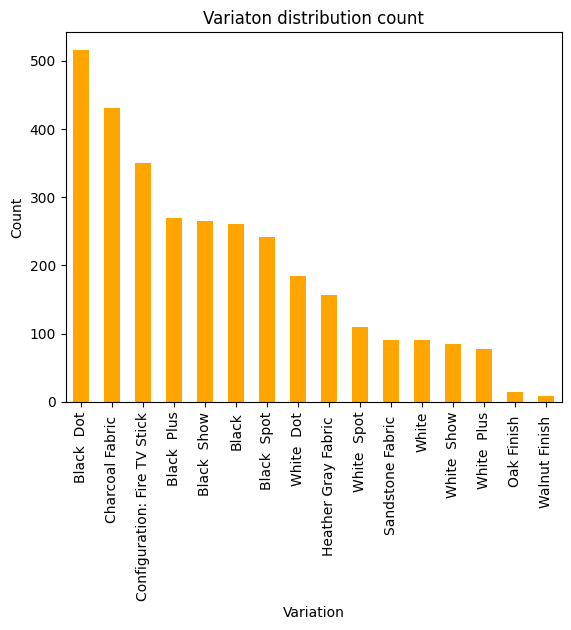

In [ ]:
data['variation'].value_counts().plot.bar(color = 'orange')
plt.title("Variaton distribution count")
plt.xlabel("Variation")
plt.ylabel("Count")
plt.show()

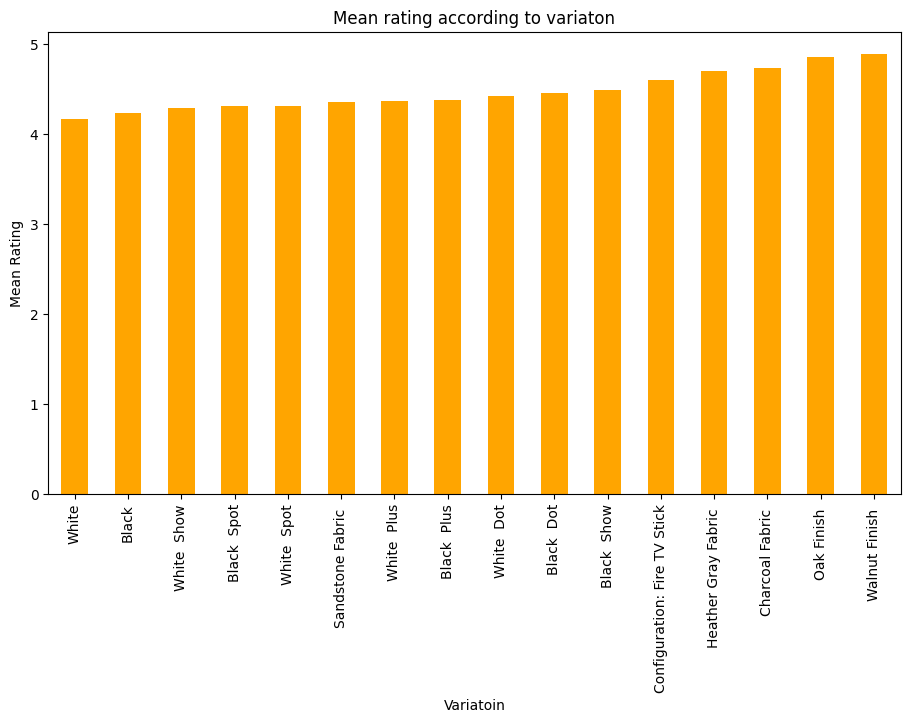

In [ ]:
data.groupby("variation")['rating'].mean().sort_values().plot.bar(color="orange", figsize=(11,6))
plt.title("Mean rating according to variaton")
plt.xlabel("Variatoin")
plt.ylabel("Mean Rating")
plt.show()

In [ ]:
## Convert TEXT to VECTOR
cv = CountVectorizer(stop_words='english')
words = cv.fit_transform(data.verified_reviews)

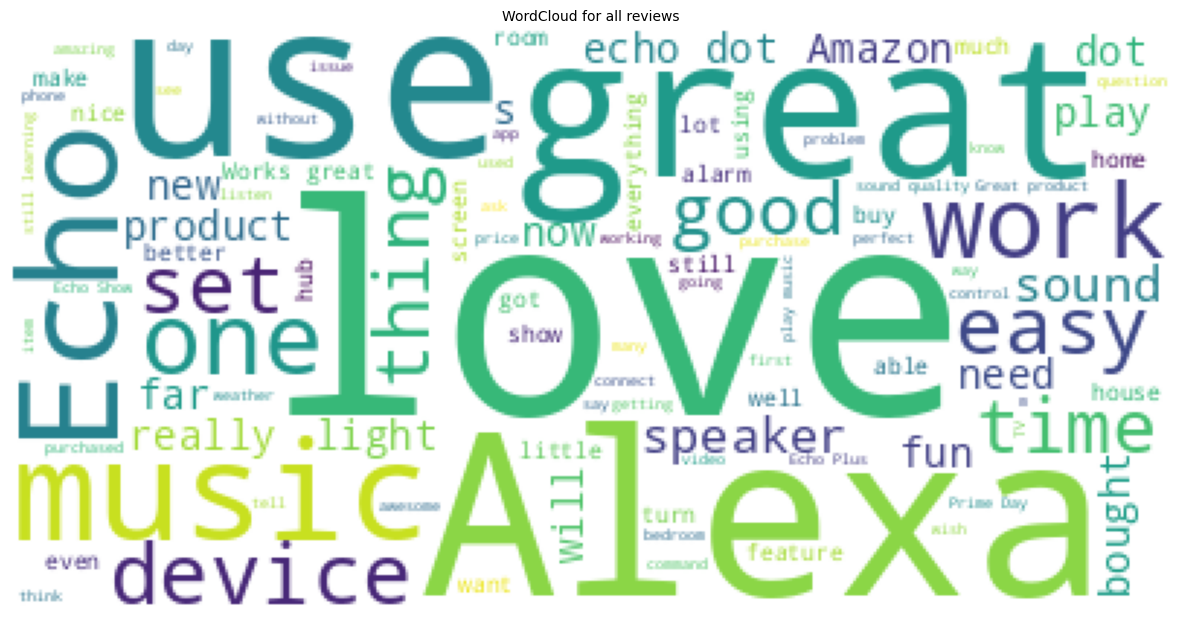

In [ ]:
# combine all reviwes
reviews = " ".join([review for review in data['verified_reviews']])

#initialize wordcloud object
wc = WordCloud(background_color="white", max_words = 100)

# Generate and plot wordcloud
plt.figure(figsize=(15,15))
plt.imshow(wc.generate(reviews))
plt.title("WordCloud for all reviews", fontsize=10)
plt.axis("off")
plt.show()

Finding most important words in each feedback category

In [ ]:
# combine all reviews fir each feedback category and splitting them into individual words

neg_reviews = " ".join([review for review in data[data['feedback']==0]['verified_reviews']])
neg_reviews = neg_reviews.lower().split()

pos_reviews = " ".join([review for review in data[data['feedback']==1]['verified_reviews']])
pos_reviews = pos_reviews.lower().split()

# finding words from revoews which are present in that feedback category only
unique_negative = [x for x in neg_reviews if x not in pos_reviews]
unique_negative = " ".join(unique_negative)

unique_positive = [x for x in pos_reviews if x not in neg_reviews]
unique_positive = " ".join(unique_positive)

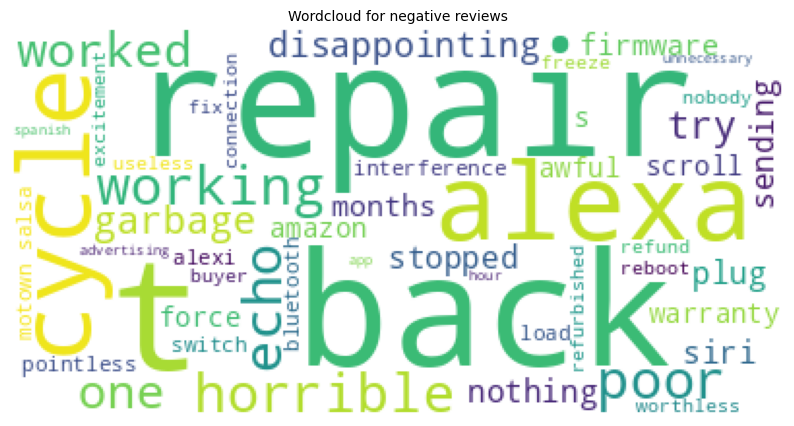

In [ ]:
wc = WordCloud(background_color="white", max_words=50)

# GEnerate and plot wordcloud
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(unique_negative))
plt.title("Wordcloud for negative reviews", fontsize=10)
plt.axis('off')
plt.show()

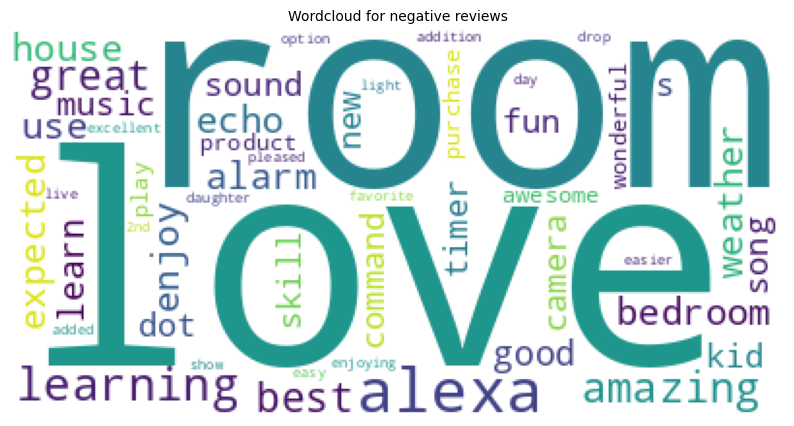

In [ ]:
wc = WordCloud(background_color="white", max_words=50)

# GEnerate and plot wordcloud
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(unique_positive))
plt.title("Wordcloud for negative reviews", fontsize=10)
plt.axis('off')
plt.show()

# Pre Processing and Model Building
1. Replace any non alphabetical charater with empty string / space
2. Convert to lower case

In [ ]:
corpus = []
stemmer = PorterStemmer()
for i in range (0, data.shape[0]):
  review = re.sub('[a-zA-Z]',"", data.iloc[i]["verified_reviews"])
  review = review.lower().split()
  review = [stemmer.stem(word) for word in review if not word in STOPWORDS]
  review = "".join(review)
  corpus.append(review)

Using CountVectorizer to create bag of words

In [ ]:
cv = CountVectorizer(max_features = 2500)

# Storing independent and dependent variables in X and Y
X = cv.fit_transform(corpus).toarray()
y=data['feedback'].values

In [ ]:
# Saving countvectorizer
pickle.dump(cv, open('countVectorizer.pkl','wb'))

In [ ]:
print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (3149, 72)
y Shape: (3149,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=15)

print(f"X train: {X_train.shape}")
print(f"X test: {X_test.shape}")
print(f"y train: {y_train.shape}")
print(f"y test: {y_test.shape}")

X train: (2204, 72)
X test: (945, 72)
y train: (2204,)
y test: (945,)


In [ ]:
scaler = MinMaxScaler()

X_train_scl = scaler.fit_transform(X_train)
X_test_scl = scaler.fit_transform(X_test)

In [ ]:
# Saving the scaler model
pickle.dump(scaler, open('scaler.pkl','wb'))

# TESTING MODELS

## Random Forest

In [ ]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train_scl,y_train)

RandomForestClassifier()

In [ ]:
# Accuracy of Random Forest
print("Training Accuracy: ", model_rf.score(X_train_scl,y_train))
print("Testing Accuracy: ", model_rf.score(X_test_scl,y_test))

Training Accuracy:  0.926950998185118
Testing Accuracy:  0.91005291005291


In [ ]:
# Predicting on the test set
y_preds = model_rf.predict(X_test_scl)

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_preds)

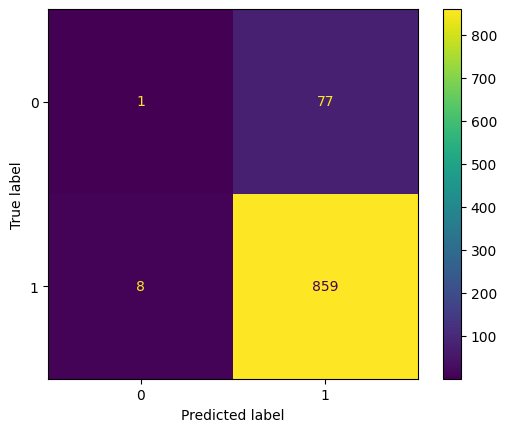

In [ ]:
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = model_rf.classes_)
cm_display.plot()
plt.show()

### k fold cross valiadation

In [ ]:
accuracies = cross_val_score(estimator = model_rf, X = X_train_scl, y=y_train, cv=10)

print("Accuracy: ", accuracies.mean())
print("Standard Variance: ", accuracies.std())

Accuracy:  0.9183319621554915
Standard Variance:  0.003469577768866702


## XG Boost

In [ ]:
model_xgb = XGBClassifier()
model_xgb.fit(X_train_scl,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Accuracy of XGBoost
print("Training Accuracy: ", model_xgb.score(X_train_scl,y_train))
print("Testing Accuracy: ", model_xgb.score(X_test_scl,y_test))

Training Accuracy:  0.9196914700544465
Testing Accuracy:  0.9174603174603174


In [ ]:
y_preds = model_xgb.predict(X_test)

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_preds)

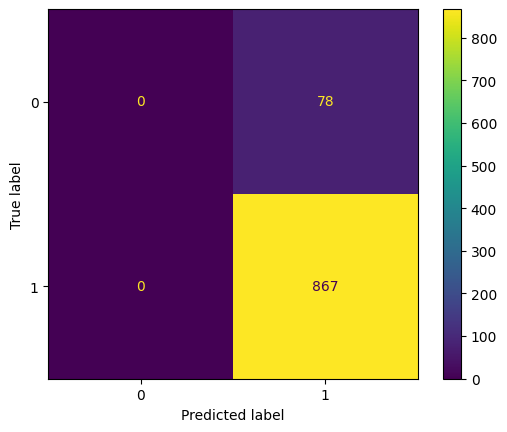

In [ ]:
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = model_xgb.classes_)
cm_display.plot()
plt.show()

In [ ]:
# Saving the XGB classifier
pickle.dump(model_xgb, open("model_xgb.pkl",'wb'))

## Decision Tree Classifier

In [ ]:
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train_scl, y_train)

DecisionTreeClassifier()

In [ ]:
# Accuracy of XGBoost
print("Training Accuracy: ", model_dt.score(X_train_scl,y_train))
print("Testing Accuracy: ", model_dt.score(X_test_scl,y_test))

Training Accuracy:  0.926950998185118
Testing Accuracy:  0.91005291005291


In [ ]:
y_preds = model_dt.predict(X_test)

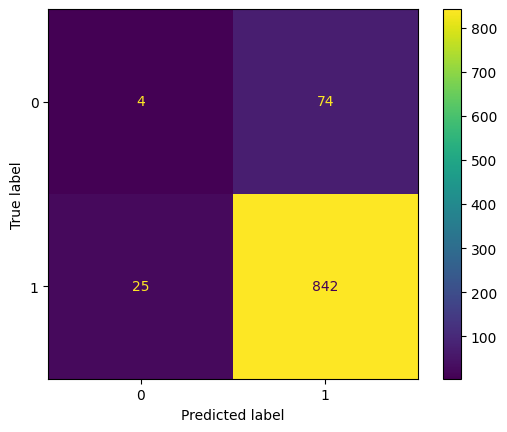

In [ ]:
cm = confusion_matrix(y_test, y_preds)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = model_dt.classes_)
cm_display.plot()
plt.show()

In [ ]:
files.download('countVectorizer.pkl')
files.download('scaler.pkl')
files.download('model_xgb.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>